In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed/clean_energy.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.set_index("Datetime", inplace=True)

In [3]:
df["Year"] = df.index.year
df["Month"] = df.index.month
df["Day"] = df.index.day
df["Hour"] = df.index.hour
df["DayOfWeek"] = df.index.dayofweek

In [4]:
df.head()

,PJME_MW,Year,Month,Day,Hour,DayOfWeek
Datetime,,,,,,
2002-12-31 01:00:00,26498.0,2002,12,31,1,1
2002-12-31 02:00:00,25147.0,2002,12,31,2,1
2002-12-31 03:00:00,24574.0,2002,12,31,3,1
2002-12-31 04:00:00,24393.0,2002,12,31,4,1
2002-12-31 05:00:00,24860.0,2002,12,31,5,1


In [5]:
df["Lag_1"] = df["PJME_MW"].shift(1) #1 hour ago
df["Lag_24"] = df["PJME_MW"].shift(24) #1 day ago
df["Lag_168"] = df["PJME_MW"].shift(168) #1 week ago

In [6]:
df["Rolling24"] = df["PJME_MW"].rolling(24).mean()
df["Rolling168"] = df["PJME_MW"].rolling(168).mean()

In [7]:
df = df.dropna()

In [8]:
features = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfWeek",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "Rolling24",
    "Rolling168"
]
X = df[features]
y = df["PJME_MW"]

In [ ]:
split = int(len(df) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-0.71,-0.63, 1.12,..., 0.11, 0.09,-0.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Year','Month','Day',...,'Lag_168','Rolling24','Rolling168']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1693
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [11]:
predictions = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1012.4240110921623
RMSE: 1363.1039202744928
R²  : 0.9564310589774664


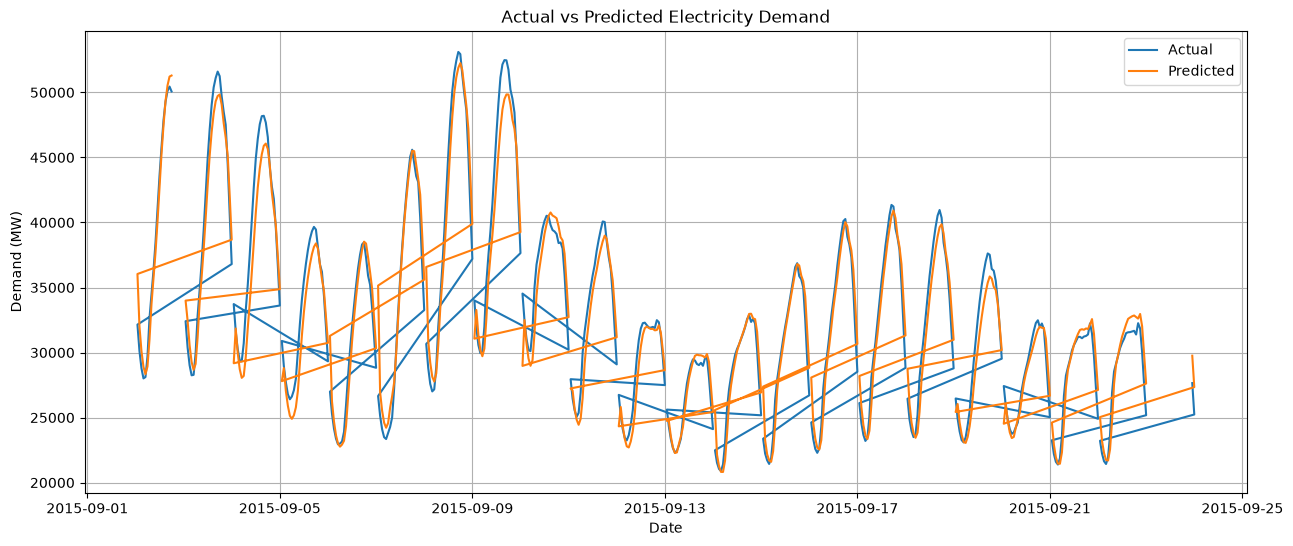

In [15]:
plt.figure(figsize=(15,6))
plt.plot(y_test.index[:500], y_test.iloc[:500], label="Actual")
plt.plot(y_test.index[:500], predictions[:500], label="Predicted")
plt.title("Actual vs Predicted Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import joblib
joblib.dump(model, "../models/linear_regression_model.pkl")
print("Model saved successfully!")

Model saved successfully!
